#### Build a model which will predict the profit a startup company can have when Administrative amount, Research and Developement spend amount, Marketing amount along with state of the organization is specified

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Datasets/50_Startups.csv")
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [4]:
df.shape

(50, 5)

In [5]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


{'whiskers': [<matplotlib.lines.Line2D at 0x1c848162fd0>,
 'caps': [<matplotlib.lines.Line2D at 0x1c848163250>,
 'boxes': [<matplotlib.lines.Line2D at 0x1c848062e90>],
 'medians': [<matplotlib.lines.Line2D at 0x1c8481634d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1c848163610>],
 'means': []}

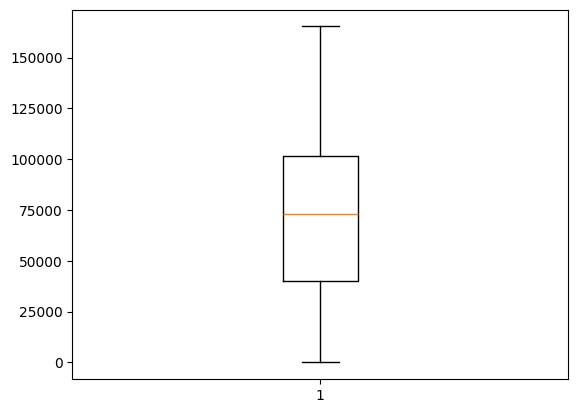

In [6]:
plt.boxplot(df['R&D Spend'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1c848238b90>,
 'caps': [<matplotlib.lines.Line2D at 0x1c848238e10>,
 'boxes': [<matplotlib.lines.Line2D at 0x1c848238a50>],
 'medians': [<matplotlib.lines.Line2D at 0x1c848239090>],
 'fliers': [<matplotlib.lines.Line2D at 0x1c8482391d0>],
 'means': []}

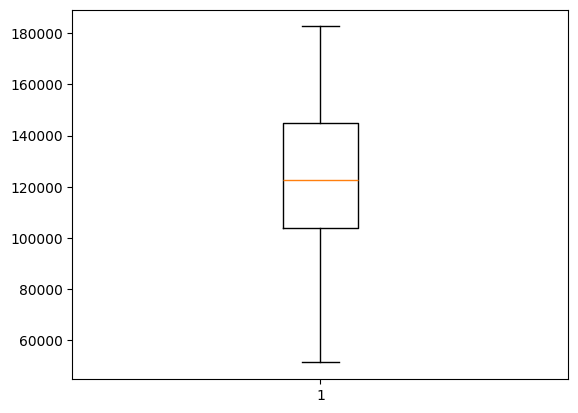

In [7]:
plt.boxplot(df['Administration'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1c84a3d8e10>,
 'caps': [<matplotlib.lines.Line2D at 0x1c84a3d9090>,
 'boxes': [<matplotlib.lines.Line2D at 0x1c84a3d8cd0>],
 'medians': [<matplotlib.lines.Line2D at 0x1c84a3d9310>],
 'fliers': [<matplotlib.lines.Line2D at 0x1c84a3d9450>],
 'means': []}

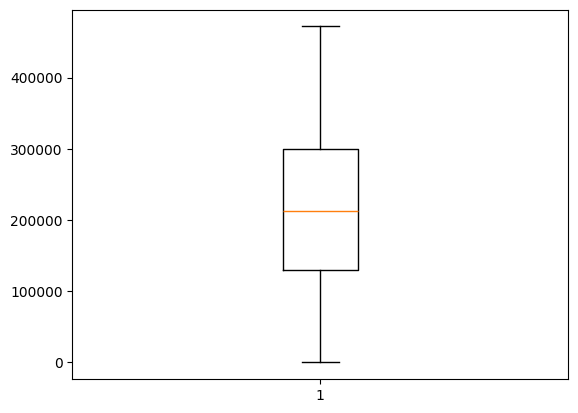

In [8]:
plt.boxplot(df['Marketing Spend'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1c84a41b9d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1c84a41bc50>,
 'boxes': [<matplotlib.lines.Line2D at 0x1c84a41b890>],
 'medians': [<matplotlib.lines.Line2D at 0x1c84a41bed0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1c84a464050>],
 'means': []}

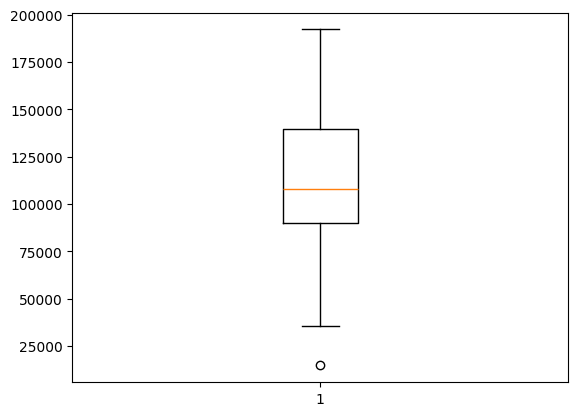

In [9]:
plt.boxplot(df['Profit'])

In [13]:
df['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

In [45]:
df2 = pd.get_dummies(df, columns=['State'], dtype=int)
df2.head()

# encode state column
# remove state column from original df
# add encoded column in original df

,R&D Spend,Administration,Marketing Spend,Profit,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,0,1
1,162597.70,151377.59,443898.53,191792.06,1,0,0
2,153441.51,101145.55,407934.54,191050.39,0,1,0
3,144372.41,118671.85,383199.62,182901.99,0,0,1
4,142107.34,91391.77,366168.42,166187.94,0,1,0


In [15]:
X = df2.drop('Profit', axis = 1)
X.head()

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0,0,1
1,162597.70,151377.59,443898.53,1,0,0
2,153441.51,101145.55,407934.54,0,1,0
3,144372.41,118671.85,383199.62,0,0,1
4,142107.34,91391.77,366168.42,0,1,0


In [16]:
y = df2['Profit']
y.head()

0    192261.83
1    191792.06
2    191050.39
3    182901.99
4    166187.94
Name: Profit, dtype: float64

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

In [19]:
X_train.head()

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
40,28754.33,118546.05,172795.67,1,0,0
17,94657.16,145077.58,282574.31,0,0,1
18,91749.16,114175.79,294919.57,0,1,0
0,165349.20,136897.80,471784.10,0,0,1
27,72107.60,127864.55,353183.81,0,0,1


In [21]:
X_test.head()

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
12,93863.75,127320.38,249839.44,0,1,0
14,119943.24,156547.42,256512.92,0,1,0
4,142107.34,91391.77,366168.42,0,1,0
8,120542.52,148718.95,311613.29,0,0,1
45,1000.23,124153.04,1903.93,0,0,1


In [22]:
from sklearn.linear_model import LinearRegression

In [44]:
model = LinearRegression()     # created model

In [24]:
model.fit(X_train, y_train)    # trained model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
test_pred = model.predict(X_test)

In [26]:
test_pred

array([130810.7853991 , 151612.82041841, 175383.55497879, 151500.08714558,
        44652.99867675, 190991.79819778, 101755.79637235, 112546.6656388 ,
        44413.64661017, 111167.76641456])

In [29]:
from sklearn.metrics import r2_score
r2_score(y_test, test_pred)

0.9438509847891489

In [30]:
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_test, test_pred)

10155.830400378542

In [32]:
print('Coefficient : ', model.coef_)

Coefficient :  [ 8.31966697e-01 -3.67454189e-02  2.67817833e-02 -8.61802405e+01
  1.23042055e+03 -1.14424031e+03]


In [33]:
print('Intercept : ', model.intercept_)

Intercept :  49476.14575599582


In [34]:
rd = 150000
adm = 6799
mark = 450000
state = 'California'

ca = 0
fl = 0
ny = 0

if state == 'California':
    ca = 1
elif state == 'Florida':
    fl = 1
elif state == 'New York':
    ny = 1


In [35]:
ca, fl, ny

(1, 0, 0)

In [36]:
model.predict([[rd, adm, mark, ca, fl, ny]])

C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([185986.9404409])

In [42]:
values = pd.DataFrame([[rd, adm, mark, ca, fl, ny]])
values

,0,1,2,3,4,5
0,150000,6799,450000,1,0,0


In [43]:
model.predict(values)

C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([185986.9404409])